In [65]:
from io import StringIO
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy import nan
from functions import * # Import functions from the .py file

from pylab import rcParams
rcParams["figure.figsize"] = 16, 4

PAYLOADSIZE = 12 
NUM_16RND = 6

if PAYLOADSIZE % 2 != 0:
    print("Alarm! the payload size is not even.")

# --- THE FIX: Overwrite the readfile function to handle 4 columns and empty lines ---
def readfile(filename):
    # 1. Add 'pkt_num' to absorb the extra column, and skip_blank_lines to ignore the gaps
    df = pd.read_csv(
        filename,
        skiprows=0,
        header=None,
        delimiter="|",
        on_bad_lines='skip',
        skip_blank_lines=True, 
        names=["time_rx", "pkt_num", "frame", "rssi"], 
        dtype=str
    )
    df.dropna(inplace=True)
    
    # 2. Cleanup whitespace
    df.time_rx = df.time_rx.str.strip()
    df.frame = df.frame.str.strip()
    df = df[df.frame.str.contains("packet overflow") == False]
    
    # 3. Cleanup RSSI (removes "CRC error" and keeps the number)
    df.rssi = df.rssi.str.strip().str.split(" ", expand=True).iloc[:,0]
    df.rssi = df.rssi.astype('int')
    
    # 4. Parse frame sequence and payload
    df = df[df.frame.str.len() >= 6]
    df['seq'] = df.frame.apply(lambda x: int(x[3:5], base=16))
    df['payload'] = df.frame.apply(lambda x: x[6:])
    
    # 5. Drop the pkt_num column since we don't need it
    df = df.drop(columns=['frame', 'pkt_num'])
    df.reset_index(inplace=True, drop=True)
    
    return df

## Log file

**For a fair comparison between groups, must follow the output format below**
<br>$\color{red}{\text{timestamp\_rx }| \text{ len [hex] } \text{ seq [hex] } \text{ payload [hex] }| \text{rssi} }$
<br>$\text{ len [hex]}$ = payload length + 1 (seq. field length [1B])
<br>$\text{ payload [hex]}$ should start with the pseudo sequence number [2B], indicates the starting byte's position in the file.
***
*Example log file output for one frame with reciever timestamp xxxx, frame length, seq number and random payload, received signal strength.*
<br>15:17:18.394 |0f 46 bd f8 f7 ea 41 ac 1b be 05 a0 7f d2 09 d4 |  -91 CRC error
<br>$\color{red}{\text{delimiter for four variables is "|" and delimiter for the payload each byte is the space " ".}}$

In [66]:
# define the file name
filename = "50K_5_converted"
# import file to jupyter notebook
df = readfile("./" + filename + ".csv")
# check the imported data first 10 lines
df.head(10)

,time_rx,rssi,seq,payload
0,06:38:55.561,-86,16,19 67 14 cd 23 50 1a 85 20 c1 19 92
1,06:38:56.129,-86,40,1e 56 0e 8d 20 a2 22 d0 1a d9 1b 0c
2,06:38:56.410,-86,52,14 8a 2e 28 24 44 5c 4b 0f 9e 23 8f
3,06:38:56.695,-84,64,28 01 2d 49 1e 88 18 08 1c 1c 19 f4
4,06:38:56.977,-84,76,1a 82 1a 94 aa 1a aa a8 a1 54 09 25
5,06:38:57.259,-85,88,20 ed 1f bc 1d 6e 27 8b 20 c9 1e ec
6,06:38:57.544,-84,100,1a c7 2a 2a 1f 01 18 65 2b de 15 9a
7,06:38:57.828,-86,112,24 74 20 fc 18 00 21 7c 1a b5 14 c7
8,06:38:58.110,-85,124,22 03 1e 32 2a 94 24 70 11 58 1a 93
9,06:38:58.392,-86,136,1f 0a 19 b7 1c 14 24 3a 1f 91 19 f5


In [67]:
# delete packets of invalid length (aka. error in length field at variable receiver length config) (PAYLOADSIZE + 2B pesudo sequence number)
test = df[df.payload.apply(lambda x: len(x)==((PAYLOADSIZE)*3-1))]
test.reset_index(inplace=True)

# Time

## Definition

**Evaluation metric**
<br>*File Transmission Time: the total latency that certain amount of Data $F$ is delivered to the destination.*
<br> $File\ Delay = Rx\_timestamp[N] - Rx\_timestamp[0]$
<br> where $N$ is the last packet
***
**Interesting to look at**:
<br>*Timestamp difference*: $\Delta T[i] = Rx\_timestamp[i] - Tx\_timestamp[i]$
1. *Worst-case packet delay*: the delay of the packet that takes the longest time to traverse.
2. *Packet delay variation*: the std of the packet delay.

In [68]:
# UPDATED: Convert the string timestamps back to datetime objects
t_start = pd.to_datetime(df.time_rx.iloc[0], format='%H:%M:%S.%f')
t_end = pd.to_datetime(df.time_rx.iloc[-1], format='%H:%M:%S.%f')

# compute the file delay
# Force absolute difference to handle overnight or out-of-order timestamps
file_delay_s = abs((t_end - t_start).total_seconds())

# Recalculate data rate manually for your notes
# (225 packets * 12 bytes * 8 bits) / 80.765 seconds = ~267 bps

#print(f"The time it takes to transfer the file is : {file_delay}, which is {file_delay_s} seconds.")

# Reliability

## Definition

**Evaluation metric**
<br>*Quality of data transfer.*
<br>*Bit Reliability*: The ratio of data bits correctly delivered to the data sink.
<br>*Bit Error Rate*: The ratio of data bits incorrectly delivered to the data sink.
$$Bit\ Reliability = 1 - BER = 1 - \frac{Number\ of\ wrong\ bit}{Total\ Number\ of\ bit\ received}$$
<br>*Achieved Data Rate*: The bit error rate is calculated based on the received data only. Missing packets do not affect the bit error rate, but are reflected in the achievable data rate.

## Statistics

In [69]:
# compute the BER for all received packets
# Use PAYLOADSIZE (12) to match your data
ber = compute_ber(test, PACKET_LEN=PAYLOADSIZE)
bit_reliability = (1-ber)*100

print(f"Bit error rate [%]: {(ber*100):.8f}")

if len(test) < 1:
    print("Data rate [bit/s]: More than one packet required for analysis.")
else:
    # UPDATED: Calculate bits (Packets * 12 bytes * 8 bits) / seconds
    d_rate = (len(test) * PAYLOADSIZE * 8) / file_delay_s
    print(f"Data rate [bit/s]: {d_rate:.8f}")

The total number of packets transmitted by the tag is 229.
Bit error rate [%]: 36.80208333
Data rate [bit/s]: 19.90858641


Note: if individual packets have a high bit-error rate...


Text(0.5, 0, 'Packet Index')

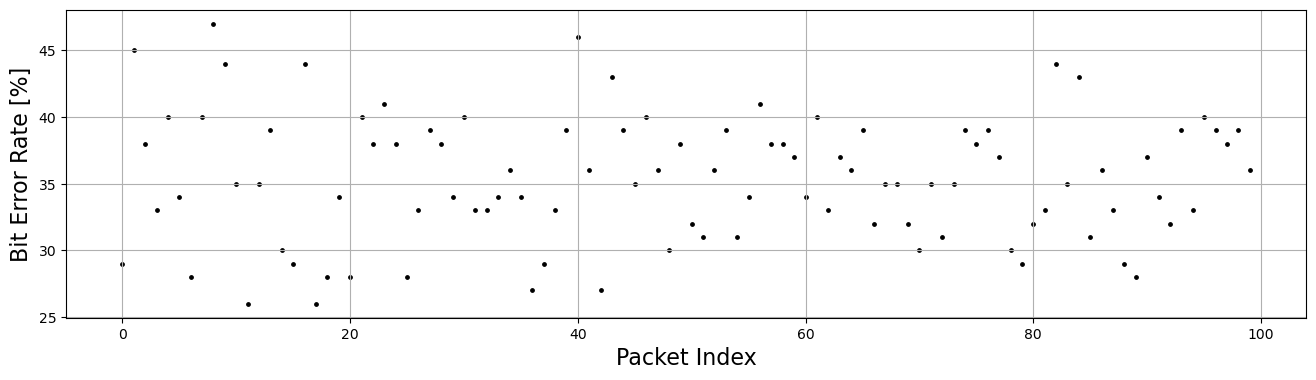

In [70]:
# BER for each packet
# Updated Plot Block for Test 3
print("Note: if individual packets have a high bit-error rate...")

# 1. Ensure we only plot rows that have a valid payload
valid_df = test[test['payload'].notna()]

# 2. Plot using the filtered 'valid_df' and ensure PACKET_LEN matches PAYLOADSIZE
# We use PAYLOADSIZE from your previous block
plt.scatter(
    range(len(valid_df)), 
    [compute_ber_packet(row, PACKET_LEN=PAYLOADSIZE)[0] for (_, row) in valid_df.iterrows()], 
    marker='o', s=6, color='black'
)

plt.grid()
plt.ylabel('Bit Error Rate [%]', fontsize=16)
plt.xlabel('Packet Index', fontsize=16)

# Distance

## Definition

**The communication distance of the system.**
<br>$D_{1}$: the distance between carrier<->backscatter_tag[m]
<br>$D_{2}$: the distance between backscatter_tag<->receiver[m]
<br> Distance metric = $D_{1}^2D_{2}^2$
<br>

In [71]:
# record the distance
dis_carrier_tag = 1
dis_tag_rx = 4

dis_metric = dis_carrier_tag**2*dis_tag_rx**2
print(f"Distance metric is: {dis_metric}")

Distance metric is: 16


# Radarplot

**Please pay attention to the unit**
<br> <font color='red'>Time</font>: use second as unit
<br> <font color='red'>Reliability</font>: use the percent as unit
<br> <font color='red'>Distance</font>: use meter as unit
<br>**Metics = [Time(s), Reliability(%), Distance(m)]**
<br> <font color='red'>Always keep the reference in your plot.</font>
<br> Tips: for ploting, time metric uses $\frac{1}{Time}*1000$ as the time metric, the higher the value the better the system performance

[482.204, 63.197916666666664, 16]


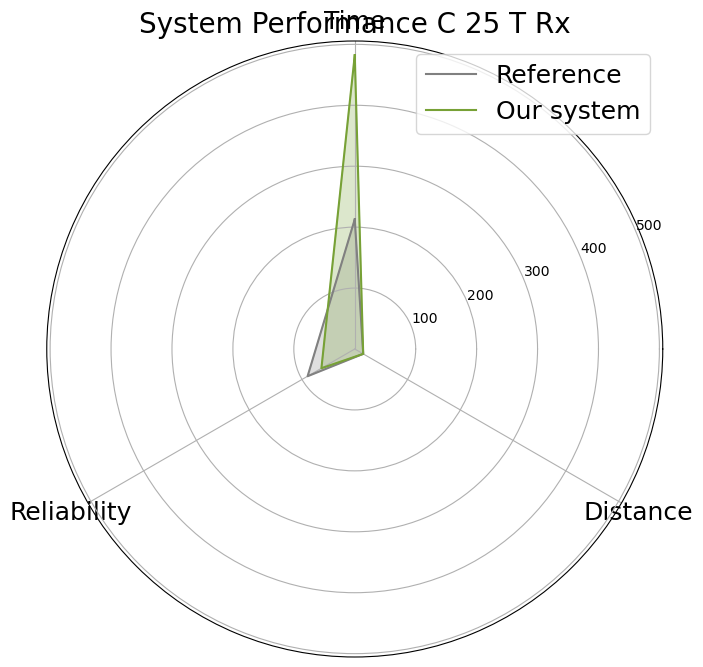

In [72]:
metrics = [file_delay_s, bit_reliability, dis_metric]

system_ref_baseline_c25 = [57.284, 96.41, 16] # C ->(25cm) Tag
system_ref_baseline_c50 = [np.float64(100.318), 92.21428571428572, 16] # C ->(50cm) Tag
system_ref_baseline_middle = [0, 0, 0] # C -> (150) Tag -> (150) Receiver
system_ref_baseline_rx50 = [np.float64(212.826), 89.36160714285715, 16] # Tag ->(50cm) Receiver
system_ref_baseline_rx25 = [np.float64(121.055), 91.36607142857143, 16] # # Tag ->(25cm) Receiver


print(metrics)
#                                                 25cm                            3m
title = "System Performance C 25 T Rx" # Carrier ------> Tag -> Receiver (Carrier --> Receiver)
radar_plot(metrics, system_ref=system_ref_baseline_rx50, title=title)

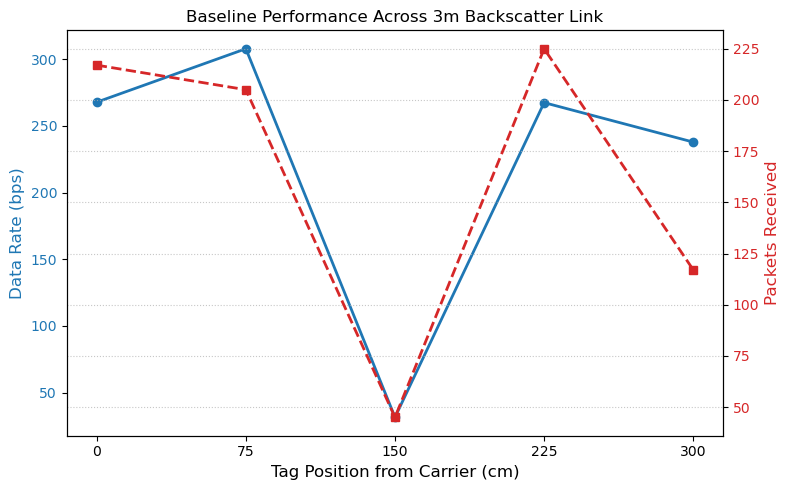

In [73]:

import matplotlib.pyplot as plt

# Your collected data
distances = [0, 75, 150, 225, 300]
data_rates = [267.80, 307.84, 31.48, 267.44, 237.85]
packets = [217, 205, 45, 225, 117]

fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:blue'
ax1.set_xlabel('Tag Position from Carrier (cm)', fontsize=12)
ax1.set_ylabel('Data Rate (bps)', color=color, fontsize=12)
ax1.plot(distances, data_rates, marker='o', color=color, linewidth=2, label="Data Rate")
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(distances)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Packets Received', color=color, fontsize=12)
ax2.plot(distances, packets, marker='s', linestyle='--', color=color, linewidth=2, label="Packets")
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Baseline Performance Across 3m Backscatter Link")
fig.tight_layout()  
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig("summary_performance.pdf") # Saves the image for LaTeX
plt.show()